In [1]:
import pandas as pd

df_cdr= pd.read_csv("../data/raw/fraud_detection_cdr.csv")
df_text= pd.read_csv("../data/raw/BETTER30.csv")



In [2]:
print("CDR DATA SHAPE:", df_cdr.shape)
print("TEXT DATA SHAPE:", df_text.shape)

df_cdr.head()
df_text.head()



CDR DATA SHAPE: (101174, 17)
TEXT DATA SHAPE: (650, 7)


,CONVERSATION_ID,CONVERSATION_STEP,TEXT,CONTEXT,LABEL,FEATURES,ANNOTATIONS
0,6,1,"Good morning, this is [Your Name]'s personal a...",Standard opening exchange,neutral,NaN,NaN
1,6,2,"Hello, my name is Jamie. I'm interested in vol...",Encourages the caller's interest,neutral,"welcoming, positive_tone",NaN
2,6,3,"Yes, I'm really passionate about environmental...",Reinforces anyone can volunteer,neutral,inclusive,NaN
3,6,4,"Great, how do I sign up, and where can I find ...",Demonstrates flexibility,neutral,"helpful_tone, offers_options",NaN
4,6,5,"Could you send me the link, please? And my ema...",Fulfills caller's request quickly,neutral,prompt_action,NaN


In [3]:
print("CDR Columns:")
print(df_cdr.columns)

print("\nTEXT Columns:")
print(df_text.columns)

CDR Columns:
Index(['Phone Number', 'Account Length', 'VMail Message', 'Day Mins',
       'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge',
       'Night Mins', 'Night Calls', 'Night Charge', 'Intl Mins', 'Intl Calls',
       'Intl Charge', 'CustServ Calls', 'isFraud'],
      dtype='str')

TEXT Columns:
Index(['CONVERSATION_ID', 'CONVERSATION_STEP', 'TEXT', 'CONTEXT', 'LABEL',
       'FEATURES', 'ANNOTATIONS'],
      dtype='str')


In [4]:
df_cdr['isFraud'].value_counts(normalize= True)




isFraud
False    0.895902
True     0.104098
Name: proportion, dtype: float64

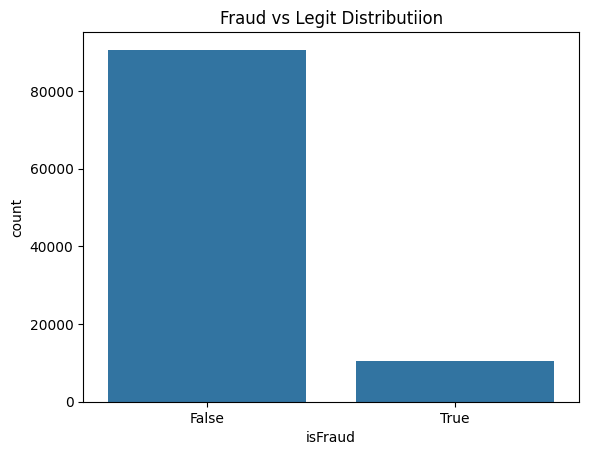

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x= 'isFraud', data= df_cdr)
plt.title("Fraud vs Legit Distributiion")
plt.show()


In [6]:
df_cdr.describe()


,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000,101174.000000
mean,323.597149,18.142645,587.080798,267.207613,64.958811,655.512526,267.166930,34.358125,646.786643,261.673187,13.900142,20.291269,5.737798,4.347635,2.559640
std,1418.073651,75.826932,2193.094319,947.963370,133.515808,2473.445436,932.914437,36.248577,2368.028491,884.963021,16.178685,25.033214,8.196367,2.761911,2.401904
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.300000,20.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,69.000000,0.000000,222.300000,88.000000,23.920000,223.300000,88.000000,22.220000,223.200000,88.000000,6.220000,8.800000,2.000000,2.280000,2.000000
50%,202.000000,0.000000,262.200000,202.000000,32.600000,268.200000,202.000000,24.440000,268.200000,202.000000,9.220000,20.200000,4.000000,2.920000,2.000000
75%,240.000000,22.000000,326.275000,224.000000,82.200000,329.200000,224.000000,32.020000,329.200000,224.000000,20.440000,22.800000,8.000000,4.940000,3.000000
max,21111.000000,1111.000000,111111.110000,21111.000000,1111.990000,111111.200000,21111.000000,211.990000,111111.110000,21111.000000,211.920000,211.900000,211.000000,11.920000,11.000000


In [7]:
df_cdr = df_cdr.apply(pd.to_numeric, errors='coerce')



In [8]:
df_cdr.isnull().sum()

Phone Number      101174
Account Length         0
VMail Message          0
Day Mins               0
Day Calls              0
Day Charge             0
Eve Mins               0
Eve Calls              0
Eve Charge             0
Night Mins             0
Night Calls            0
Night Charge           0
Intl Mins              0
Intl Calls             0
Intl Charge            0
CustServ Calls         0
isFraud                0
dtype: int64

In [9]:
df_cdr = df_cdr.drop(columns=['Phone Number'])

In [10]:
df_cdr.groupby('isFraud').mean()

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
isFraud,,,,,,,,,,,,,,,
False,316.179089,18.789325,570.329984,264.215982,64.642064,639.999380,264.212429,34.113644,631.440004,258.804153,13.931364,19.986469,5.763487,4.333314,2.536925
True,387.439518,12.577098,731.244045,292.954615,67.684846,789.023978,292.594379,36.462208,778.865084,286.365078,13.631432,22.914480,5.516711,4.470883,2.755127


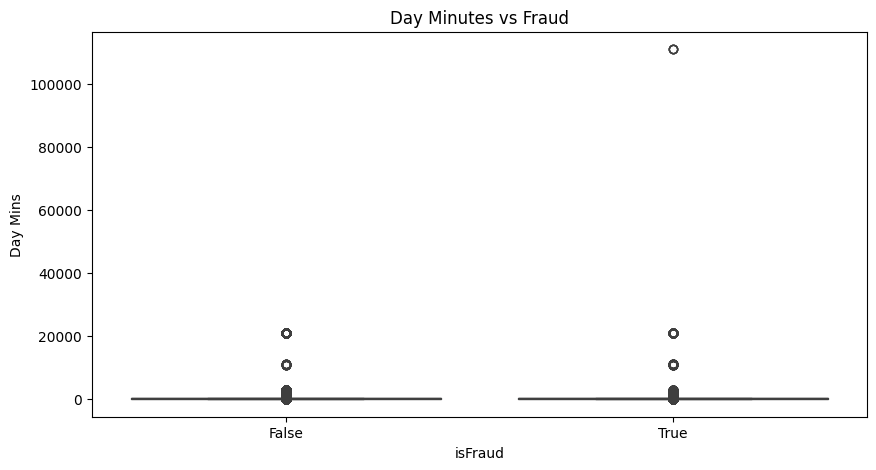

In [11]:
import seaborn as sns
import matplotlib.pyplot as ply

plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y='Day Mins', data=df_cdr)
plt.title("Day Minutes vs Fraud")
plt.show()

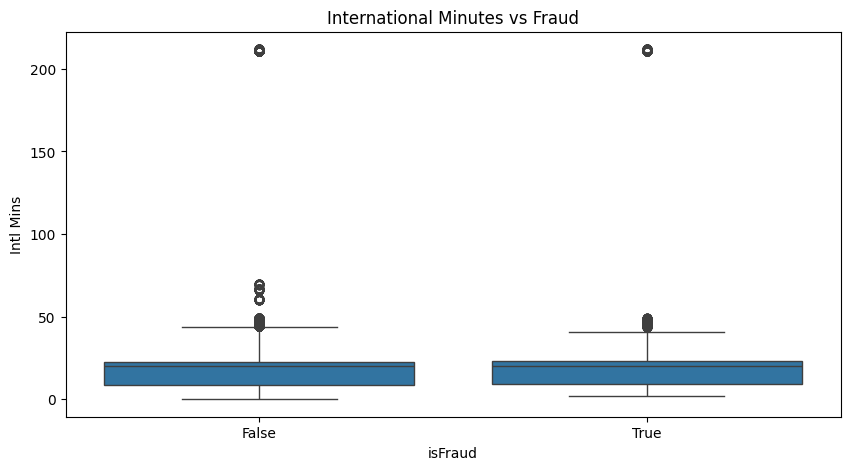

In [37]:
import seaborn as sns
import matplotlib.pyplot as ply

plt.figure(figsize=(10,5))
sns.boxplot(x='isFraud', y='Intl Mins', data=df_cdr)
plt.title("International Minutes vs Fraud")
plt.show()